This notebook does the same as predictor_corrector jl but does not include multithreading

In [2]:
using LinearAlgebra, BlockArrays
using JLD
using PyPlot
using Plots

using NPZ
using Printf
# profiling tools
using JET

using ProfileView
# using Profile
using BenchmarkTools
using HDF5

In [3]:
parse(Float64, "0.5")

0.5

# Main

In [6]:
j2_list = [0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,
           0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.09]
j2_list = [0.03]
length(j2_list)

1

Min and maxt: 
-90.0 90.0
initial βJ: 
18.93637405357614
initial T: 
0.05280842030109505
Total energy = -0.9886859966642595

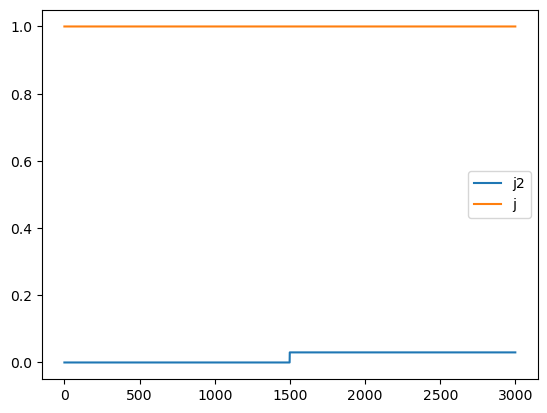

PyObject <matplotlib.legend.Legend object at 0x33a80aa70>

In [7]:
const Nt::Int64 = 3_000 # size of the matrix holdin the g(t1,t2)
const origin_i::Int64 = 1_500 # index where the t=0 is located
const dt::Float64 = 0.06 # discretization time
const J2_magnitude::Float64  = 0.03 # kinetic coupling
const σ::Float64  = 0.15# integration constant sets initial temperature
const J_magnitude::Float64 = 1.0 # value of interaction coupling after quench
const J_preq::Float64 = 1.0 # value of interaction coupling before quench

# make a time range with the origin at the center
time_range = LinRange(-origin_i*dt, (Nt-origin_i)*dt, Nt);
tmin = minimum(time_range)

# value for the quench
J2 = zeros(Nt)
# step quench
J2[origin_i:end] .= J2_magnitude 
# bump quench

J = ones(Nt)
J[1:origin_i] .= J_preq
J[origin_i:end] .= J_magnitude 


print("Min and maxt: \n")
print(minimum(time_range)," ", maximum(time_range), "\n")

print("initial βJ: \n")
β = 2.0*acos(σ/J_preq)*J_preq*(1/σ)
print(β, '\n')
print("initial T: \n")
print(1/β, "\n")

E0 = - J_preq*sqrt(1- (σ/J_preq)^2)
print("Total energy = ", E0)

plt.figure()
plt.plot(real(J2), label="j2")
plt.plot(real(J), label="j")
plt.legend()


In [8]:
#### creates a grid of xy values for evaluating an plotting
function meshgrid(xin::LinRange,yin::LinRange)
    nx=length(xin)
    ny=length(yin)
    xout=zeros(ny,nx)
    yout=zeros(ny,nx)
    for jx=1:nx
        for ix=1:ny
            xout[ix,jx]=xin[jx]
            yout[ix,jx]=yin[ix]
        end
    end
    return (x=xout, y=yout)
  end
  

function eq_g!(ret::Matrix{ComplexF64}, t1 , t2::Array{Float64},σ::Float64,j::Float64)
    # calculates the equuilibrium solutions for times t1 and t2. notice how we modify the value of ret
    # ret is the matrix that is being modified
    # t1,t2: arrays or scalars containig the coordinates
    # σ, J: scalars that set the parameters of the sysyem
    θ = acos(σ/j)
    ret .= @. 2 *log( σ/(j *cosh( θ *1im + σ *(t1 -t2))))
    # indicate that it does not return anything
    nothing 
end


function create_G(T1::Matrix{Float64} ,T2::Matrix{Float64} ,step_number::Int64, origin_index::Int64)
    # initializes the green's function
    # T1,T2: arrays that represent the meshgrid of the t1-t2 plane
    # σ, J: scalars that set the parameters of the sysyem
    # step_number: the size of the matrix
    # origin_index: indicates the position of the origin in t1,t2 plane
    
    G = complex(zeros(Nt,Nt))
    # fill all the quadrants and then remove the post quench part
    eq_g!(G,T1,T2, σ, J_preq)
    # quadB and A
    G[1:end, origin_index+1:end] .= NaN +NaN*im  # 0.0 + 0.0im # 
    # quadD and A
    G[origin_index+1:end, 1:end] .= NaN +NaN*im  # 0.0 + 0.0im # NaN +NaN*im 
    G[diagind(G)].= 0.0+ 0.0im 
    
    return G
end


function integrate_trapz(y::SubArray{ComplexF64}, Δ::Float64)
    # y:  the function to be integrated
    # Δ: the discretization step 
            
    return sum(y[1:end-1] + y[2:end]) * Δ/ 2
end


function RHS_1(g::SubArray{ComplexF64}, jq::SubArray{Float64}, j2::SubArray{Float64}, tn::Int64)
    # calculates the right hand side of the kadanoff-baym equations for the predictor corrector method
    # g: slice of the two-time green's function at the current tn timestep  
    # tn: curreent horizontal time step
    # tm: max vertical time steo
    # jq: the function for the interaction coupling
    # j2: function for the kinetic coupling

    # calculate the first integral up to tn
    t3 = 1:tn
    integrand = @. @views  - jq[tn]*jq[t3]*( exp(g[t3]) + exp(conj(g[t3])) ) - 2*j2[tn]*j2[t3]
    ∫1 = integrate_trapz(@views(integrand[t3]), dt)

    return ∫1 
end

function RHS_2(g::SubArray{ComplexF64}, jq::SubArray{Float64}, j2::SubArray{Float64}, tn::Int64, tm::Int64 )
    # calculates the right hand side of the kadanoff-baym equations for the predictor corrector method
    # g: slice of the two-time green's function at the current tn timestep  
    # tn: curreent horizontal time step
    # tm: max vertical time steo
    # jq: the function for the interaction coupling
    # j2: function for the kinetic coupling

    # calculate the second integral up to tm
    t3 = 1:tm
    integrand = @. @views   2*jq[tn]*jq[t3]*exp(g[t3]) + 2*j2[tn]*j2[t3]
    ∫2 = integrate_trapz(@views(integrand[t3]), dt)

    return ∫2
end


RHS_2 (generic function with 1 method)

In [9]:
# ------------------------------------------------------------------------------------------
# MAIN
# -----------------------------------------------------------------------------------------
println("Initializing")

# make a grid of points and initialize the green's function
t1, t2 = meshgrid(time_range, time_range);
G_calc = create_G(t1,t2,Nt, origin_i);

# create the file name for saving into h5
mint = minimum(time_range)
maxt = maximum(time_range)
str_file_name = @sprintf("datasets/pred_sigma%f_Jtwo%f_J%f_dt%f_origin%i_mint%f_maxt%f.h5", 
                          σ, J2_magnitude, J_magnitude, dt, origin_i,mint,maxt)

# iterate over horizontal time
for n in origin_i:(Nt-1)
    # iterate over vertical time for the prediction
    if(n%500==0)
        fil = open("iterations.txt","a")
        write(fil, "loops elapsed: ", string(n), '\n')
        close(fil)
    end

    # initialize the predictor for n+1 diagonal is given by initial condition
    g_pred = complex(zeros(n+1))
    # so we can save the values for the corrector
    F1_vector = complex(zeros(n))

    # first integral up until tn is the same for all m 
    integral_tn = RHS_1(@view(G_calc[1:n,n]), @views(J[1:n]), @views(J2[1:n]), n) 

    for m in 1:n   
        # calculate the RHS of the KB equations at (tn,tm)
        integral_tm = RHS_2(@view(G_calc[1:n,n]), @views(J[1:n]), @views(J2[1:n]), n, m) 
        F1 = integral_tn + integral_tm
        F1_vector[m] = F1 # save  for future use
        # calculate the predictor
        g_pred[m] = G_calc[m,n] + dt*F1
    end
    # iterate for the corrector
    integral_tn = RHS_1(@view(g_pred[1:n+1]), @views(J[1:n+1]), @views(J2[1:n+1]), n+1) 
    for m in 1:n
        # remember that here we need n+1
        integral_tm = RHS_2(@view(g_pred[1:n+1]), @views(J[1:n+1]), @views(J2[1:n+1]), n+1, m) 
        F2 = integral_tn + integral_tm
        G_calc[m,n+1] = G_calc[m,n] + 0.5*dt*( F1_vector[m] + F2) 
        G_calc[n+1,m] = conj(G_calc[m,n+1])
    end
    
    # check for nans in the current iterations and break the loop if we find any
    if any(isnan, G_calc[1:n,n]) == true
        print("Found Nan in calculation at \n")
        print("t = ", (n-origin_i)*dt ,"\n")
        print("stopping procedure ... \n")
        break
    end   
    # save checkpoints
    if(n%100==0)
        println("Saving Checkpoint up to ", n)
        save_up_to = size(G_calc[1:n,1:n])[1]
        fid = h5open(str_file_name, "w")
        fid["values",chunk=(save_up_to,1), compress=3] = G_calc[1:n,1:n]
        close(fid)
    end
    
end

# save the final state
fid = h5open(str_file_name, "w")
fid["values",chunk=(Nt,1), compress=3] = G_calc
close(fid)

print(str_file_name)




Initializing
Saving Checkpoint up to 1500
Saving Checkpoint up to 1600
Saving Checkpoint up to 1700
Saving Checkpoint up to 1800
Saving Checkpoint up to 1900
Saving Checkpoint up to 2000
Saving Checkpoint up to 2100
Saving Checkpoint up to 2200
Saving Checkpoint up to 2300
Saving Checkpoint up to 2400
Saving Checkpoint up to 2500
Saving Checkpoint up to 2600
Saving Checkpoint up to 2700
Saving Checkpoint up to 2800
Saving Checkpoint up to 2900
datasets/pred_sigma0.150000_Jtwo0.030000_J1.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5

# Error analysis

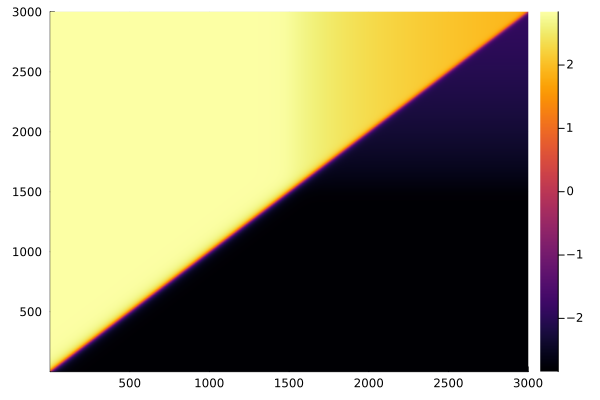

In [10]:
heatmap(imag(G_calc))


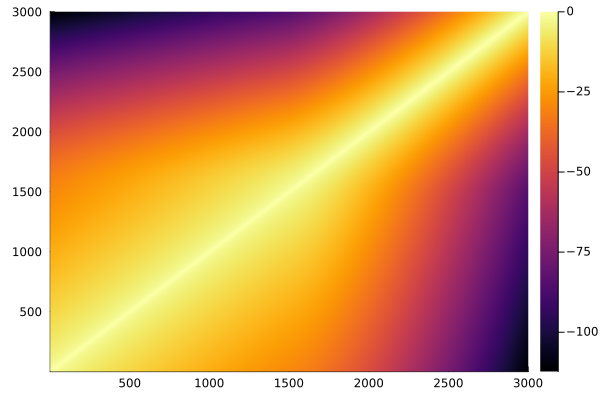

In [11]:
heatmap(real(G_calc))


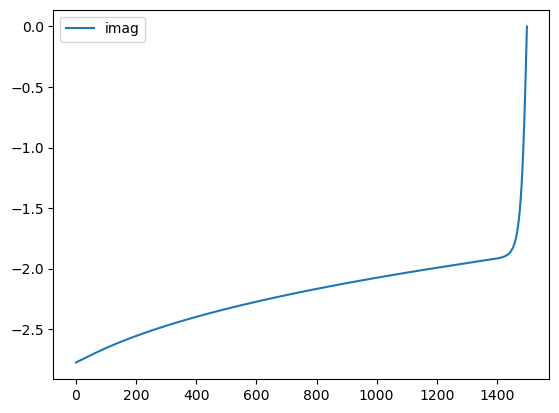

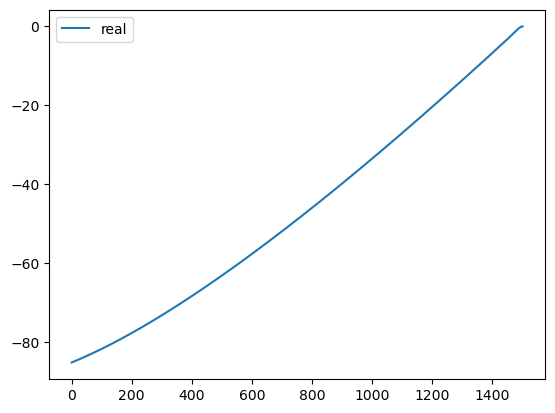

PyObject <matplotlib.legend.Legend object at 0x33a8d2380>

In [12]:
# Plotting the green's function

plt.figure()
plt.plot(imag(G_calc[origin_i:end,end]), label="imag")
plt.legend()
# display(gcf())

plt.figure()
plt.plot(real(G_calc[origin_i:end,end]), label="real")
plt.legend()
# display(gcf())

In [13]:
function calculate_energy(nint::Int64, gn::Matrix{ComplexF64}, jq::Vector{Float64}, 
                        j2_list::Vector{Float64},Dt::Float64,sig::Float64 )
    # size of the matrix
    npoints = size(gn)[1]-1
    # arrays to hold energy as a function of time
    Et1 = complex(zeros(npoints))
    Ekin = complex(zeros(npoints))
    Eq = complex(zeros(npoints))
    
    for t1 = nint+1:npoints
        gg = gn[nint:t1,t1]
        
        qintegrand = @.jq[t1]*jq[nint:t1]*(exp(gg) - exp(conj(gg))) 
        kintegrand = @. j2_list[t1]*j2_list[nint:t1]*(gg - conj(gg))
        integrand = qintegrand + kintegrand
        # integrate
        Et1[t1] = -0.5im*dt*(0.5*integrand[nint] + sum(integrand[nint+1:t1-1]) + 0.5*integrand[t1])
        Ekin[t1] = -0.5im*dt*(0.5*kintegrand[nint] + sum(kintegrand[nint+1:t1-1]) + 0.5*kintegrand[t1])
        Eq[t1] = -0.5im*dt*(0.5*qintegrand[nint] + sum(qintegrand[nint+1:t1-1]) + 0.5*qintegrand[t1])
        
    end
    # get prequench energy
    pre_e = - jq[1] * sqrt(1- (sig/jq[1])^2)

    Et1[1:origin_i] .= pre_e
    
    return Et1, Ekin,Eq,pre_e
end

calculate_energy (generic function with 1 method)

final energy: -0.9888418993127871
pre-quench energy: -0.9886859966642595
relative difference: 
-0.0001576867165648224

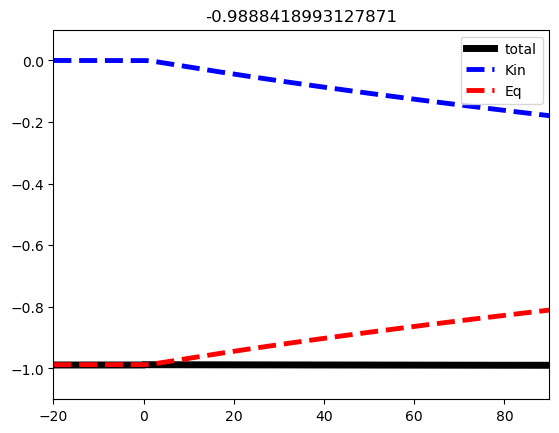

PyObject Text(0.5, 1.0, '-0.9888418993127871')

In [14]:
Et1,Ekin,Eq,preE = calculate_energy(1, G_calc, J, J2, dt, σ);

predicted = real(mean(Et1[origin_i:end]))
print("final energy: ",predicted)
print('\n')

print("pre-quench energy: ",preE)

print('\n')
print("relative difference: \n")
print( abs(real(preE) - real(predicted))/real(preE))
plt.figure()
plt.plot(time_range[2:end], real(Et1), c ="black", linewidth=5, label="total")
plt.plot(time_range[2:end], real(Ekin), c="blue", linewidth=3.5, linestyle="dashed",label="Kin")
plt.plot(time_range[2:end], real(Eq),c="red", linewidth=3.5, linestyle="dashed", label="Eq")
plt.xlim(-20,maximum(time_range))
plt.ylim(-1.1, 0.1)
plt.legend()
plt.title(predicted)

# display(gcf())


maximum change in energy: 
0.0009217611599365849
mean change in energy for the last  steps: 
8.389028873202019e-7

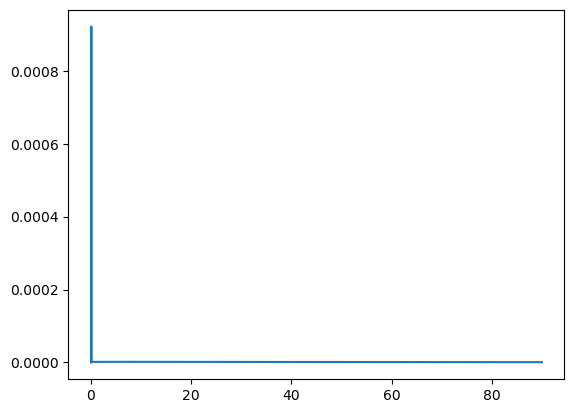

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x35fcea230>

In [15]:
# calculate the change in energy as a function of time
energy_diff = abs.(real(diff(Et1)))[origin_i-1:end]
print("maximum change in energy: \n")
print(maximum(energy_diff), "\n")
print("mean change in energy for the last  steps: \n")
print(mean(energy_diff[end-50:end]))

plt.figure()
plt.plot(time_range[origin_i+1:end],energy_diff)

# display(gcf())

# Benchmark with analytic solutions

In [11]:
# G_calc = npzread("datasets/sigma0.010000_Jtwo5.000000_J0.000000_dt0.020000_origin5000_mint-99.980000.npy");
# J2_magnitude = 5.0 + 0.0*im
G_true = complex(zeros(Nt,Nt))
# fill all the quadrants and then remove the post quench part
eq_g!(G_true,t1,t2, σ, J_magnitude)
#  ----------------------------------------------------------------
# for the kinetic quench only !!!!!!!!!!!!!!!!!!!!!!!!!
# ----------------------------------------------------------------
"""theta = acos(σ/J_preq)

# B quadrant
G_true[1:origin_i, origin_i:end] .= @. -(J2_magnitude^2) *t1[1:origin_i, origin_i:end]^2 + 2*log(
                                        σ/(J_preq*cosh(1im*theta - σ*t2[1:origin_i, origin_i:end])));

# C quadrant
G_true[origin_i:end, 1:origin_i] .= @. -(J2_magnitude^2) *t2[origin_i:end, 1:origin_i]^2 + 2*log(
                                    σ/(J_preq*cosh(1im*theta + σ*t1[origin_i:end, 1:origin_i])));

# A quadrant
G_true[origin_i:end, origin_i:end] .= @. -(J2_magnitude^2)*(t1[origin_i:end, origin_i:end]-
                                                                t2[origin_i:end, origin_i:end])^2;
"""

"theta = acos(σ/J_preq)\n\n# B quadrant\nG_true[1:origin_i, origin_i:end] .= @. -(J2_magnitude^2) *t1[1:origin_i, origin_i:end]^2 + 2*log(\n                                        σ/(J_preq*cosh(1im*theta - σ*t2[1:origin_i, origin_i:end])));\n\n# C quadrant\nG_true[origin_i:end," ⋯ 111 bytes ⋯ "   σ/(J_preq*cosh(1im*theta + σ*t1[origin_i:end, 1:origin_i])));\n\n# A quadrant\nG_true[origin_i:end, origin_i:end] .= @. -(J2_magnitude^2)*(t1[origin_i:end, origin_i:end]-\n                                                                t2[origin_i:end, origin_i:end])^2;\n"

MSE: 0.22926172003499126

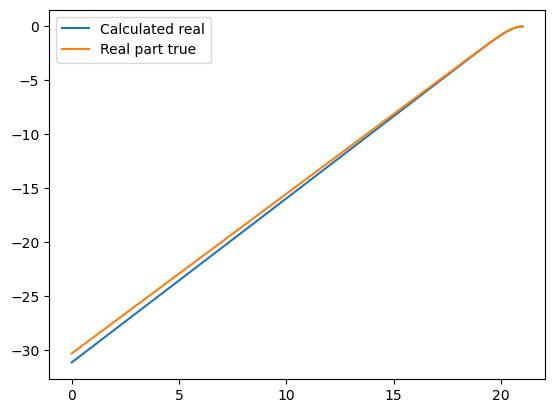

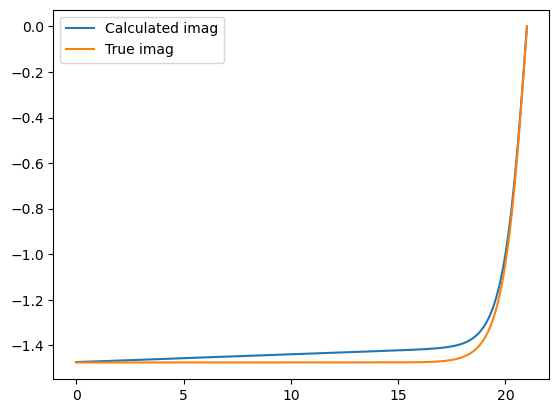

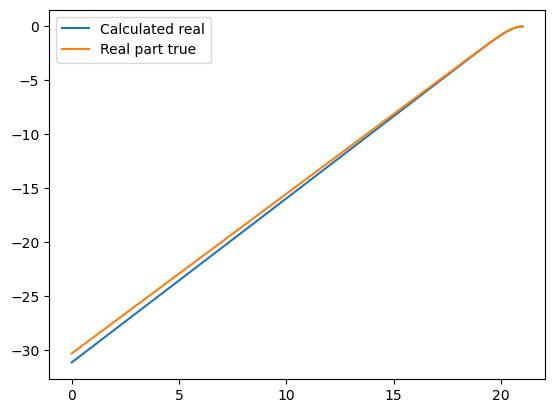

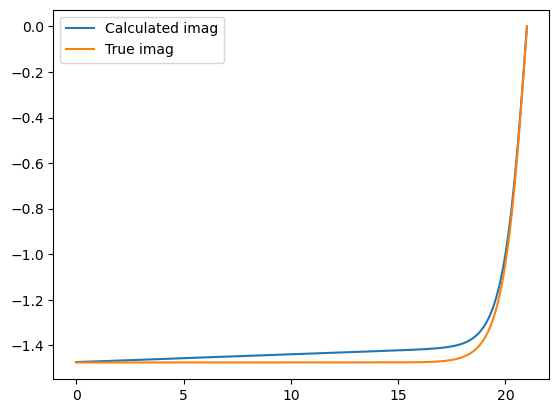

In [12]:
slice = 0
# Means sqyuared error between the two curves
MSE = sum(abs2.(G_calc[origin_i:end,Nt-slice] .- G_true[origin_i:end,Nt-slice]))/length(G_calc[origin_i:end,Nt-slice])

print("MSE: ",MSE)

plt.figure()
plt.plot(time_range[origin_i:end],real(G_calc[origin_i:end,Nt-slice]), label= "Calculated real")
plt.plot(time_range[origin_i:end],real(G_true[origin_i:end,Nt-slice]),label="Real part true")

plt.legend()
display(gcf())

plt.figure()
plt.plot(time_range[origin_i:end],imag(G_calc[origin_i:end,Nt-slice]), label= "Calculated imag")
plt.plot(time_range[origin_i:end],imag(G_true[origin_i:end,Nt-slice]),label="True imag")

plt.legend()
display(gcf())

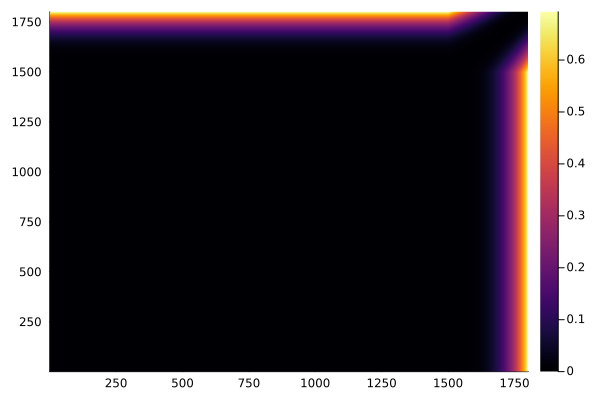

In [13]:
s_err = abs.(G_true .- G_calc).^2;

heatmap(s_err)
